# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import sklearn
import numpy as np

### Step 1. Load the data

In [55]:
df = pd.read_csv('https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv', sep=',')
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [56]:
# Assign 'Hours_Studied' as the feature matrix X
X = df[['Hours_Studied']]

# Assign 'Marks' as the target vector y
y = df['Marks']

### Step 2.b print the type of each

In [57]:
# Print the data type of both X and y to verify their structures
print("Type of X:", type(X))
print("Type of y:", type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [58]:

# Check if the target variable 'y' is numeric
if is_numeric_dtype(y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"

# Print the results
print(f"Target Type: {target_type}")
print(f"Machine Learning Task: {ml_task}")

Target Type: Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [59]:
# Get the shape of the feature matrix X
x_samples, x_columns = X.shape

# Get the shape of the target vector y
# Since y is a Series, it usually returns (rows,)
y_samples = y.shape[0]

# In case y is a Series, it doesn't have a second index for columns, 
# but for clarity in this task, we can say it has 1 target column.
y_columns = 1 if len(y.shape) == 1 else y.shape[1]

# Print the results for X
print(f"Data Matrix (X): {x_samples} samples, {x_columns} column(s)")

# Print the results for y
print(f"Target Vector (y): {y_samples} samples, {y_columns} column(s)")

Data Matrix (X): 100 samples, 1 column(s)
Target Vector (y): 100 samples, 1 column(s)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [60]:
# Generate descriptive statistics for both features and target
summary = df.describe()

# If you want to explicitly see the median as well
summary.loc['median'] = df.median()

# Display the summary table
print(summary)

        Hours_Studied       Marks
count      100.000000  100.000000
mean         5.376300   46.360200
std          2.593013   14.284805
min          1.050000   20.190000
25%          3.175000   33.675000
50%          5.565000   47.485000
75%          7.255000   57.377500
max          9.870000   73.260000
median       5.565000   47.485000


### Step 5. Plot the feature vs the target

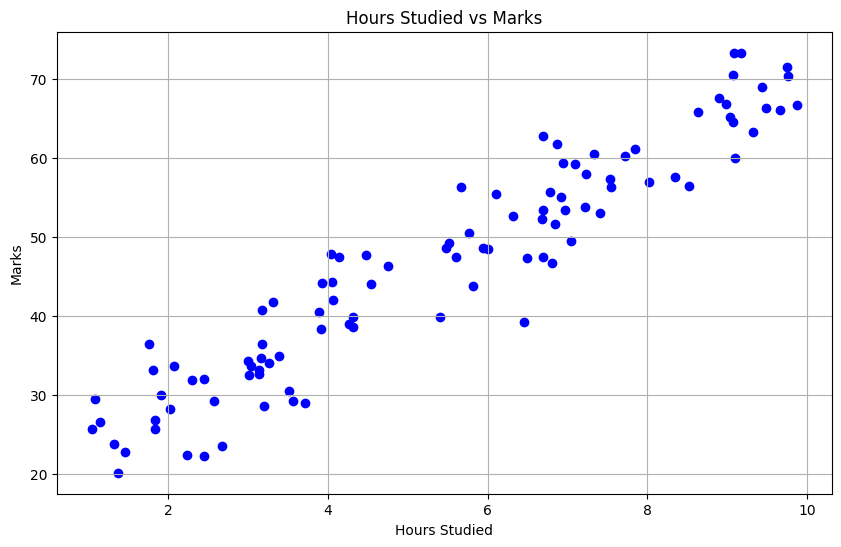

In [61]:

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Points')

# Adding labels and title
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours Studied vs Marks')
plt.grid(True)

# Show the plot
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [62]:
# Calculate the correlation between Hours_Studied and Marks
correlation_value = df['Hours_Studied'].corr(df['Marks'])

# Determine the relationship based on the correlation value
if correlation_value > 0:
    relationship = "Increasing (Positive Correlation)"
elif correlation_value < 0:
    relationship = "Decreasing (Negative Correlation)"
else:
    relationship = "None (No Correlation)"

# Print the findings
print(f"Correlation Coefficient: {correlation_value:.2f}")
print(f"The relationship is: {relationship}")

Correlation Coefficient: 0.95
The relationship is: Increasing (Positive Correlation)


### Step 7. Initialize a `LinearRegression` model

In [63]:
# Import the LinearRegression class from sklearn
from sklearn.linear_model import LinearRegression

# Initialize the model object
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [64]:
# Import the splitting utility
from sklearn.model_selection import train_test_split

# Split the data: 80% for training and 20% for testing
# random_state=42 ensures that the split is reproducible (same results every time)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 80 samples
Testing set size: 20 samples


### Step 9.a Train the model on the training set

In [65]:
# Fit the model to the training data
# This is where the model 'learns' the coefficients
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Step 9.b Identify the learned slope and the y-intercept of the model

In [66]:
# The slope (also known as the coefficient or weight)
slope = model.coef_[0]

# The y-intercept (the value of y when x is 0)
intercept = model.intercept_

# Print the results
print(f"Slope (m / b1): {slope:.4f}")
print(f"Y-Intercept (c / b0): {intercept:.4f}")

Slope (m / b1): 5.1644
Y-Intercept (c / b0): 18.5386


### Step 9.c how much marks do we get per 1 hour of study?

In [67]:
# Extract the slope value
marks_per_hour = model.coef_[0]

print(f"For every 1 hour of study, the student is expected to gain approximately {marks_per_hour:.2f} marks.")

For every 1 hour of study, the student is expected to gain approximately 5.16 marks.


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [68]:
# Since the slope is marks per 1 hour (60 minutes)
# To find marks per 10 minutes, we multiply the slope by (10/60)
marks_per_10_minutes = model.coef_[0] * (10 / 60)

print(f"A 10-minute increase in study time adds approximately {marks_per_10_minutes:.2f} marks.")

A 10-minute increase in study time adds approximately 0.86 marks.


### Step 9.e if one doesn't study at all, how much marks do they get?

In [69]:
# The y-intercept represents the predicted value when X = 0
base_marks = model.intercept_

print(f"If a student studies for 0 hours, the predicted mark is: {base_marks:.2f}")

If a student studies for 0 hours, the predicted mark is: 18.54


### Step 10. Evaluate the model on the test set

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Step 10.a: Generate predictions first!
# We use the trained model to predict marks for the test set
y_pred = model.predict(X_test)

# Step 10.b: Now you can calculate the metrics
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

RMSE: 3.84
Mean Squared Error (MSE): 14.73
R-squared Score (R2): 0.93


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [71]:
# 1. Take a sample of three rows from the test set
X_sample = X_test.head(3)
y_true = y_test.head(3)

# 2. Make predictions on these three rows
y_sample_pred = model.predict(X_sample)

# 3. Create a comparison table to check if they match
comparison = pd.DataFrame({
    'Hours Studied': X_sample['Hours_Studied'].values,
    'Actual Marks': y_true.values,
    'Predicted Marks': y_sample_pred
})

# 4. Calculate the difference (Error)
comparison['Error'] = comparison['Actual Marks'] - comparison['Predicted Marks']

print(comparison)

   Hours Studied  Actual Marks  Predicted Marks     Error
0           3.02         32.50        34.135183 -1.635183
1           8.90         67.54        64.502080  3.037920
2           6.78         55.70        53.553471  2.146529


### Step 12. Plot the data and the regression line

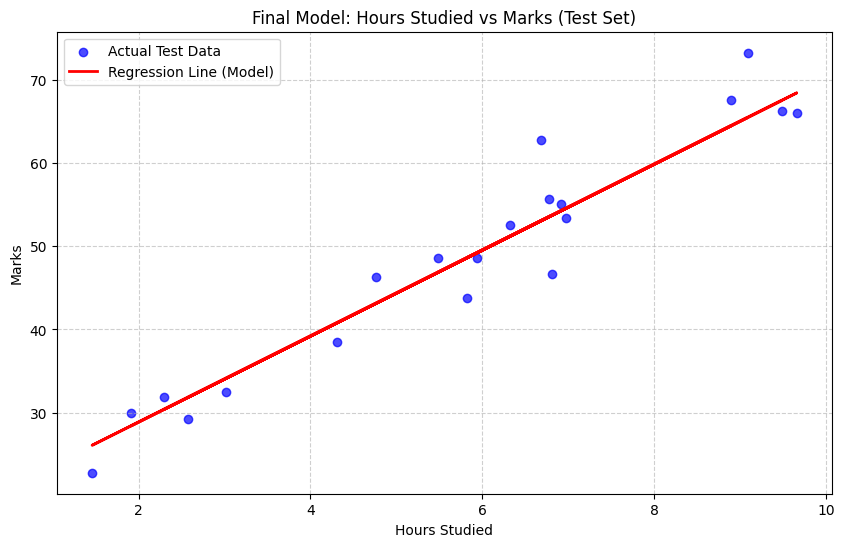

In [72]:
# 1. Plot the actual test data points (Scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data', alpha=0.7)

# 2. Plot the regression line (The model's predictions)
# We use the X_test and the corresponding y_pred we calculated earlier
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (Model)')

# 3. Add labels, title, and legend
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Final Model: Hours Studied vs Marks (Test Set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Show the plot
plt.show()